In [46]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score , confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [47]:
df=pd.read_csv(r"C:\Users\Rahul\Student-Job-Prediction\student-scores.csv")
df

,id,first_name,last_name,email,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,1,Paul,Casey,paul.casey.1@gslingacademy.com,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,2,Danielle,Sandoval,danielle.sandoval.2@gslingacademy.com,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,3,Tina,Andrews,tina.andrews.3@gslingacademy.com,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,4,Tara,Clark,tara.clark.4@gslingacademy.com,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,5,Anthony,Campos,anthony.campos.5@gslingacademy.com,male,False,5,False,10,Unknown,84,77,65,65,80,74,76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,Alan,Reynolds,alan.reynolds.1996@gslingacademy.com,male,False,2,False,30,Construction Engineer,83,77,84,73,75,84,82
1996,1997,Thomas,Gilbert,thomas.gilbert.1997@gslingacademy.com,male,False,2,False,20,Software Engineer,89,65,73,80,87,67,73
1997,1998,Madison,Cross,madison.cross.1998@gslingacademy.com,female,False,5,False,14,Software Engineer,97,85,63,93,68,94,78
1998,1999,Brittany,Compton,brittany.compton.1999@gslingacademy.com,female,True,10,True,5,Business Owner,51,96,72,89,95,88,75


In [48]:
df.shape

(2000, 17)

In [49]:
df.isnull().sum()

id                            0
first_name                    0
last_name                     0
email                         0
gender                        0
part_time_job                 0
absence_days                  0
extracurricular_activities    0
weekly_self_study_hours       0
career_aspiration             0
math_score                    0
history_score                 0
physics_score                 0
chemistry_score               0
biology_score                 0
english_score                 0
geography_score               0
dtype: int64

In [50]:
# drop unwanted columns

df.drop(columns=["id","first_name","last_name","email"],inplace=True)



In [51]:
df.head()

,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score
0,male,False,3,False,27,Lawyer,73,81,93,97,63,80,87
1,female,False,2,False,47,Doctor,90,86,96,100,90,88,90
2,female,False,9,True,13,Government Officer,81,97,95,96,65,77,94
3,female,False,5,False,3,Artist,71,74,88,80,89,63,86
4,male,False,5,False,10,Unknown,84,77,65,65,80,74,76


In [52]:
# makeing ne columns

df["total_score"] = df["math_score"] + df["history_score"] + df["physics_score"] + df["chemistry_score"] + df["biology_score"] + df["english_score"] + df["geography_score"]
df["average_score"] = df["total_score"]/7

In [53]:
# EDA


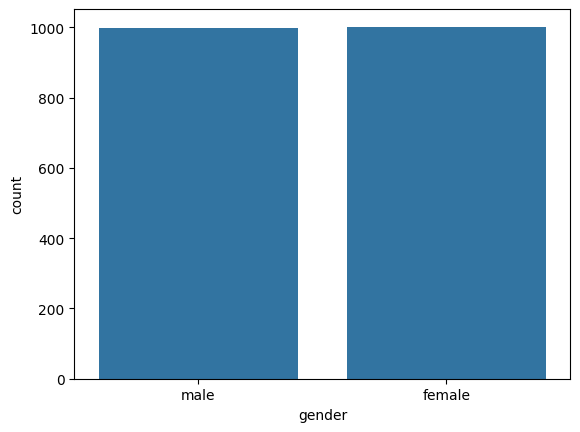

In [54]:
# Gender Distribution

sns.countplot(x="gender", data=df)
plt.show()

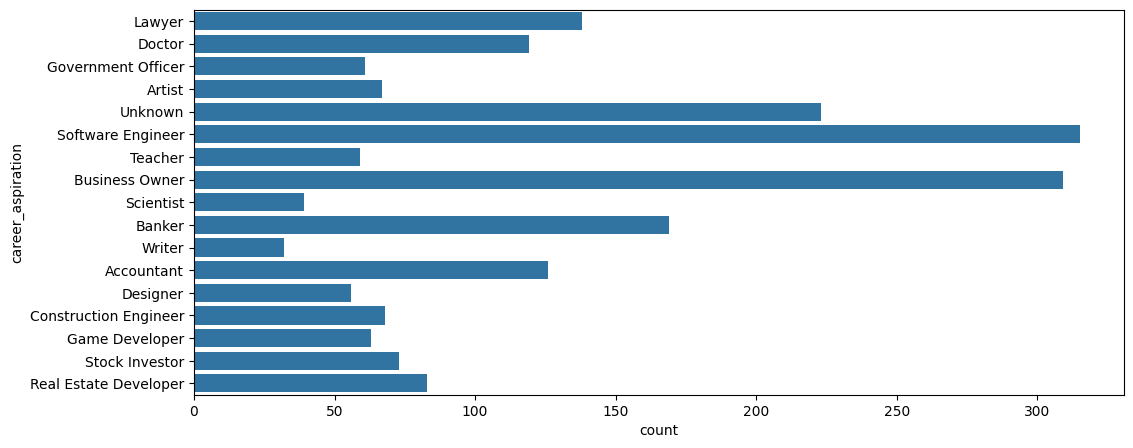

In [55]:
# Career Aspiration Distribution

plt.figure(figsize=(12,5))
sns.countplot(y="career_aspiration", data=df)
plt.show()

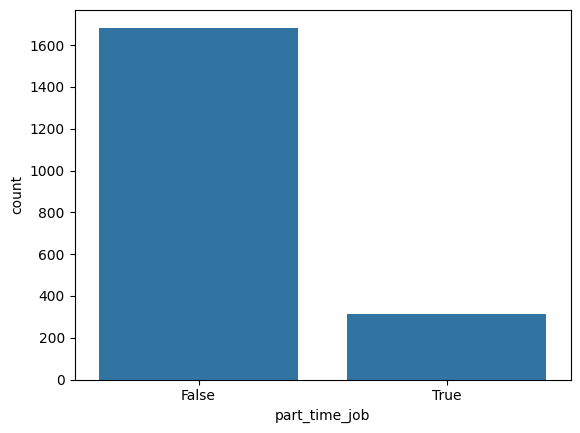

In [56]:
# part time job

sns.countplot(x="part_time_job", data=df)
plt.show()

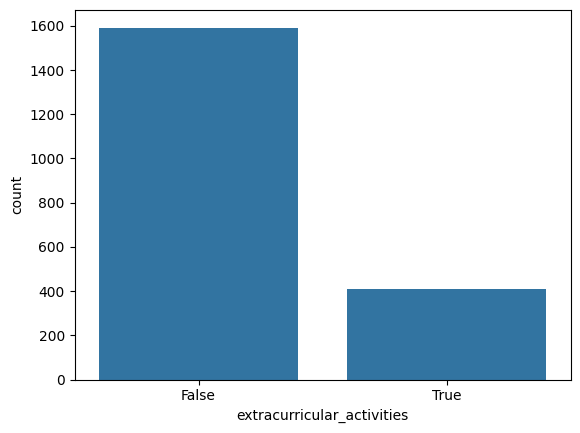

In [57]:
# extracurricular activites

sns.countplot(x="extracurricular_activities", data=df)
plt.show()

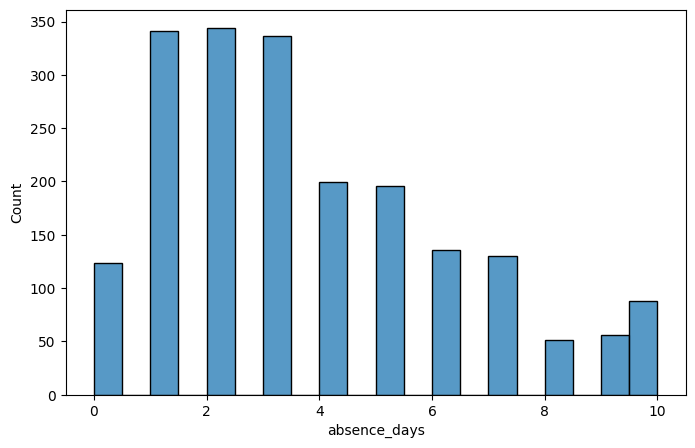

In [58]:
# absence days

plt.figure(figsize=(8,5))
sns.histplot(df["absence_days"], bins=20)
plt.show()

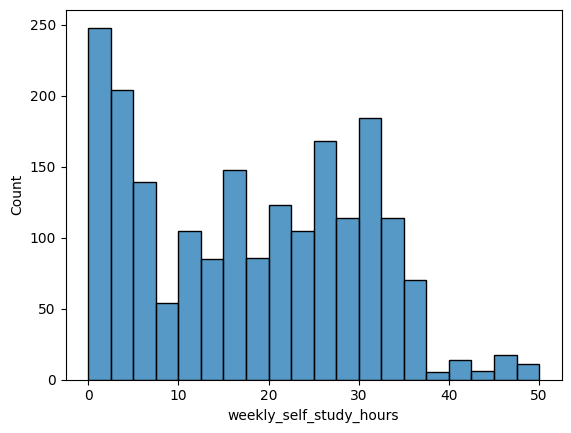

In [59]:
# weekly self study hours

sns.histplot(df["weekly_self_study_hours"], bins=20)
plt.show()

In [60]:
from sklearn.preprocessing import LabelEncoder
import pickle

# Create encoder dictionary
encoders = {}

categorical_cols = [
    "gender",
    "part_time_job",
    "extracurricular_activities",
    "career_aspiration"
]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# Save encoders
with open("labelencoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print(encoders.keys())

dict_keys(['gender', 'part_time_job', 'extracurricular_activities', 'career_aspiration'])


In [62]:
df["part_time_job"] = df["part_time_job"].astype(int)
df["extracurricular_activities"] = df["extracurricular_activities"].astype(int)

In [63]:
import pickle

encoders = pickle.load(open("labelencoders.pkl", "rb"))

for key, le in encoders.items():
    print(f"{key}: {le.classes_}")

gender: ['female' 'male']
part_time_job: [False  True]
extracurricular_activities: [False  True]
career_aspiration: ['Accountant' 'Artist' 'Banker' 'Business Owner' 'Construction Engineer'
 'Designer' 'Doctor' 'Game Developer' 'Government Officer' 'Lawyer'
 'Real Estate Developer' 'Scientist' 'Software Engineer' 'Stock Investor'
 'Teacher' 'Unknown' 'Writer']


In [64]:
df.head()

,gender,part_time_job,absence_days,extracurricular_activities,weekly_self_study_hours,career_aspiration,math_score,history_score,physics_score,chemistry_score,biology_score,english_score,geography_score,total_score,average_score
0,1,0,3,0,27,9,73,81,93,97,63,80,87,574,82.000000
1,0,0,2,0,47,6,90,86,96,100,90,88,90,640,91.428571
2,0,0,9,1,13,8,81,97,95,96,65,77,94,605,86.428571
3,0,0,5,0,3,1,71,74,88,80,89,63,86,551,78.714286
4,1,0,5,0,10,15,84,77,65,65,80,74,76,521,74.428571


In [65]:
from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(random_state=42)


In [66]:
X = df.drop("career_aspiration",axis=1)
y = df["career_aspiration"]

# Apply SMOTE to the data
X_resampled, y_resampled = smote.fit_resample(X, y)


In [67]:
X_train,X_test,y_train,y_test = train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42)

In [68]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [69]:
import pickle

pickle.dump(scaler, open("scaler.pkl", "wb"))

In [70]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.8281979458450047


In [71]:
import pickle
with open("RandomForestClassifier.pkl","wb") as f:
    pickle.dump(rf,f)

In [73]:
from sklearn.metrics import accuracy_score

pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.6825396825396826
